In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

# Load the dataset
df = pd.read_csv('phishing_url_features.csv')

In [2]:

pd.set_option('display.max_columns', None)
df

,url,URLLength,Domain,DomainLength,TLD,TLDLength,NoOfSubDomain,LetterRatioInURL,DigitRatioInURL,NoOfSpecialCharsInURL,PathLength,IsHTTPS,label
0,https://blockchaoin.info/#/,27,blockchaoin,11,info,4,0,0.740741,0.000000,7,1,1,1
1,https://www.insects.org/ced4/crush_freaks.html,46,insects,7,org,3,0,0.782609,0.021739,9,23,1,0
2,https://www.elpasotimes.com/story/opinion/edit...,118,elpasotimes,11,com,3,0,0.703390,0.135593,19,91,1,0
3,http://direct-certs.bankofamerica.com.techdbas...,147,techdbaseurl46,14,cn,2,3,0.482993,0.428571,13,22,0,1
4,https://gotham-magazine.com/lalique-unveils-ep...,53,gotham-magazine,15,com,3,0,0.830189,0.000000,9,26,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
514589,https://www.affiliaxe.com/blog/tag/our-team,43,affiliaxe,9,com,3,0,0.790698,0.000000,9,18,1,0
514590,http://www.thisisdisplay.org/collection/page/p108,49,thisisdisplay,13,org,3,0,0.775510,0.061224,8,21,0,0
514591,http://paypal.com-cgi.arabmakemoney.com/5885d8...,68,arabmakemoney,13,com,3,2,0.661765,0.161765,12,19,0,1
514592,http://www.aspavadiamond.com/themes/ok/ipad,43,aspavadiamond,13,com,3,0,0.813953,0.000000,8,15,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514594 entries, 0 to 514593
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   url                    514594 non-null  object 
 1   URLLength              514594 non-null  int64  
 2   Domain                 514581 non-null  object 
 3   DomainLength           514594 non-null  int64  
 4   TLD                    514594 non-null  object 
 5   TLDLength              514594 non-null  int64  
 6   NoOfSubDomain          514594 non-null  int64  
 7   LetterRatioInURL       514594 non-null  float64
 8   DigitRatioInURL        514594 non-null  float64
 9   NoOfSpecialCharsInURL  514594 non-null  int64  
 10  PathLength             514594 non-null  int64  
 11  IsHTTPS                514594 non-null  int64  
 12  label                  514594 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 51.0+ MB


In [4]:

# kolom numerik selain label
num_cols = df.select_dtypes(include=['number']).columns.drop('label')

# hitung skewness
skewness_values = df[num_cols].skew()

# threshold umum
skewed_features = skewness_values[
    (skewness_values > 0.5) | (skewness_values < -0.5)
].sort_values(ascending=False)

print("Skewness tiap fitur:\n")
print(skewness_values.sort_values(ascending=False))

print("\nFitur skew:\n")
print(skewed_features)

Skewness tiap fitur:

NoOfSpecialCharsInURL    11.307159
URLLength                 6.133280
NoOfSubDomain             5.643868
PathLength                3.192026
TLDLength                 2.760851
DigitRatioInURL           1.647366
DomainLength              1.144782
IsHTTPS                   0.498225
LetterRatioInURL         -1.384580
dtype: float64

Fitur skew:

NoOfSpecialCharsInURL    11.307159
URLLength                 6.133280
NoOfSubDomain             5.643868
PathLength                3.192026
TLDLength                 2.760851
DigitRatioInURL           1.647366
DomainLength              1.144782
LetterRatioInURL         -1.384580
dtype: float64


**LOG TRANSFORM**

In [5]:
df_log = df.copy()

for col in skewed_features.index:

    # hindari log(0)
    if (df_log[col] < 0).any():
        shift = abs(df_log[col].min()) + 1
        df_log[col] = np.log1p(df_log[col] + shift)

    else:
        df_log[col] = np.log1p(df_log[col])

**DATA VISUALIZATION BEFORE LOG TRANSFORM**

In [6]:
df_legit = df[df['label'] == 0]
df_phishing = df[df['label'] == 1]

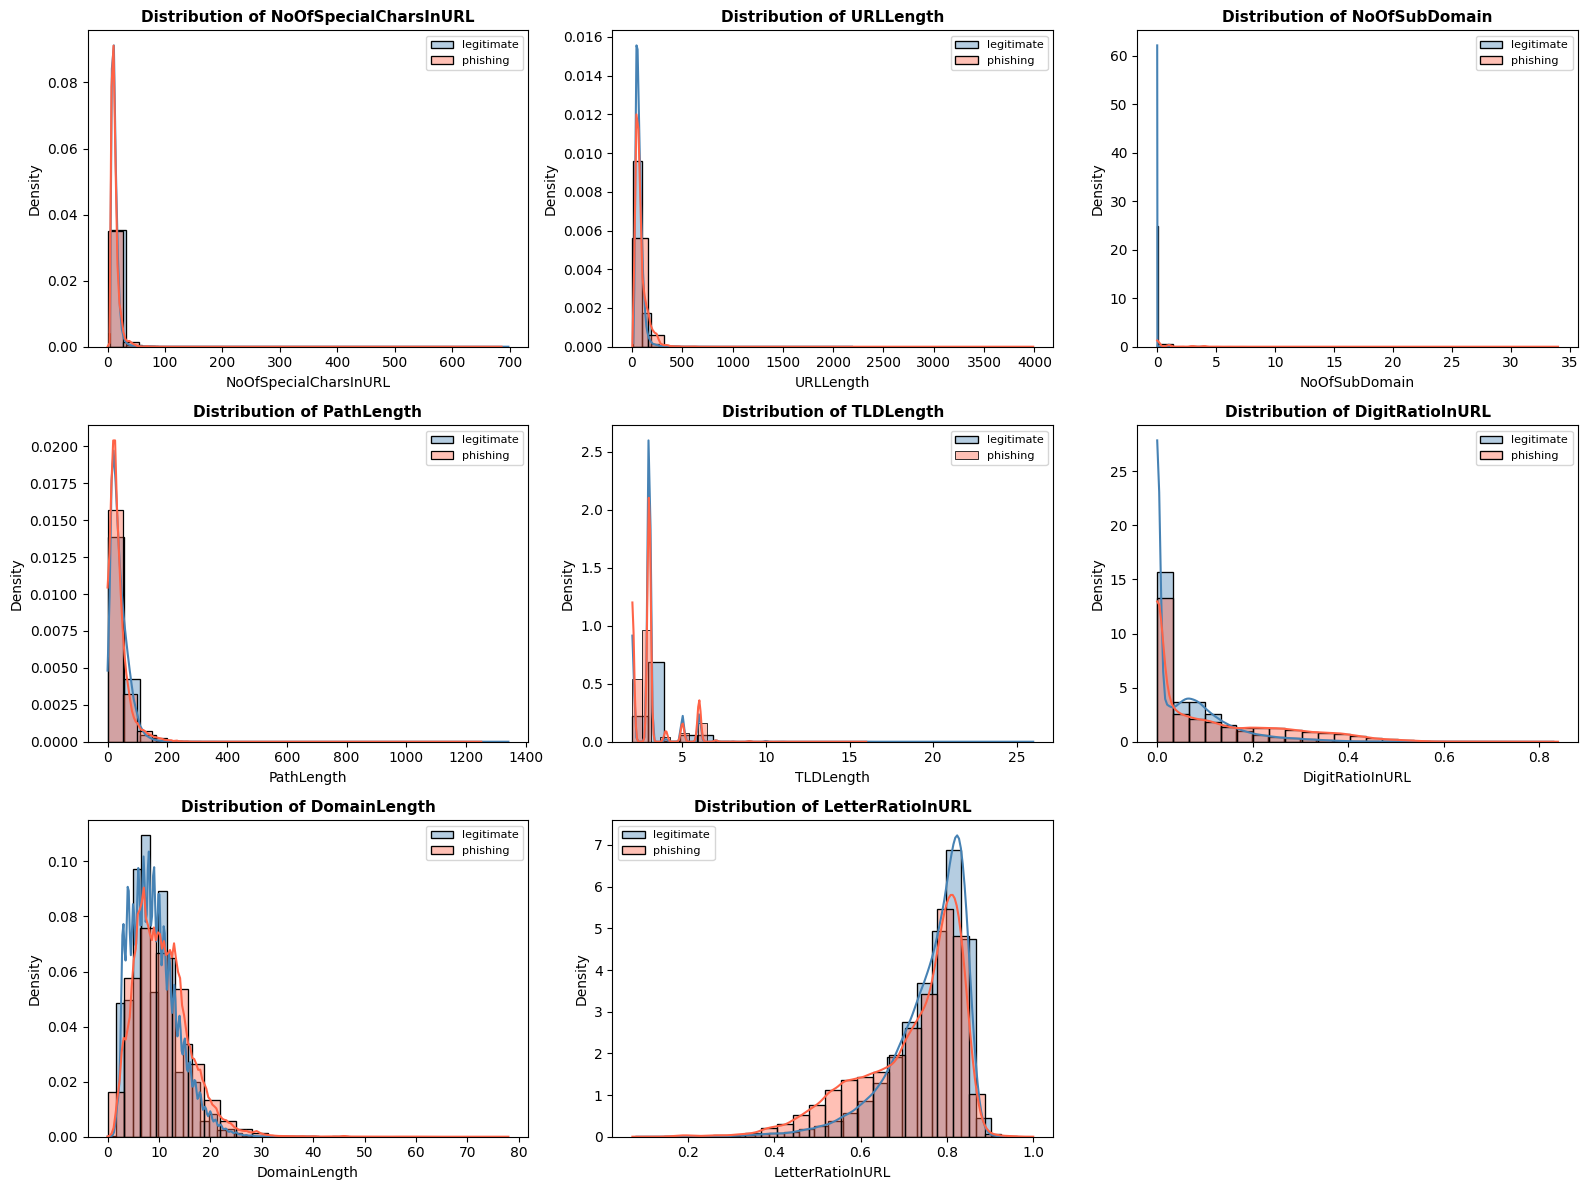

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(skewed_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(skewed_features.index):

    sns.histplot(
        df_legit[col],
        kde=True,
        stat="density",
        bins=25,
        color="steelblue",
        alpha=0.4,
        label="legitimate",
        ax=axes[i]
    )

    sns.histplot(
        df_phishing[col],
        kde=True,
        stat="density",
        bins=25,
        color="tomato",
        alpha=0.4,
        label="phishing",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**DATA VISUALIZATION AFTER LOG TRANSFORM**

In [10]:
df_log_legit = df_log[df_log['label'] == 0]
df_log_phishing = df_log[df_log['label'] == 1]

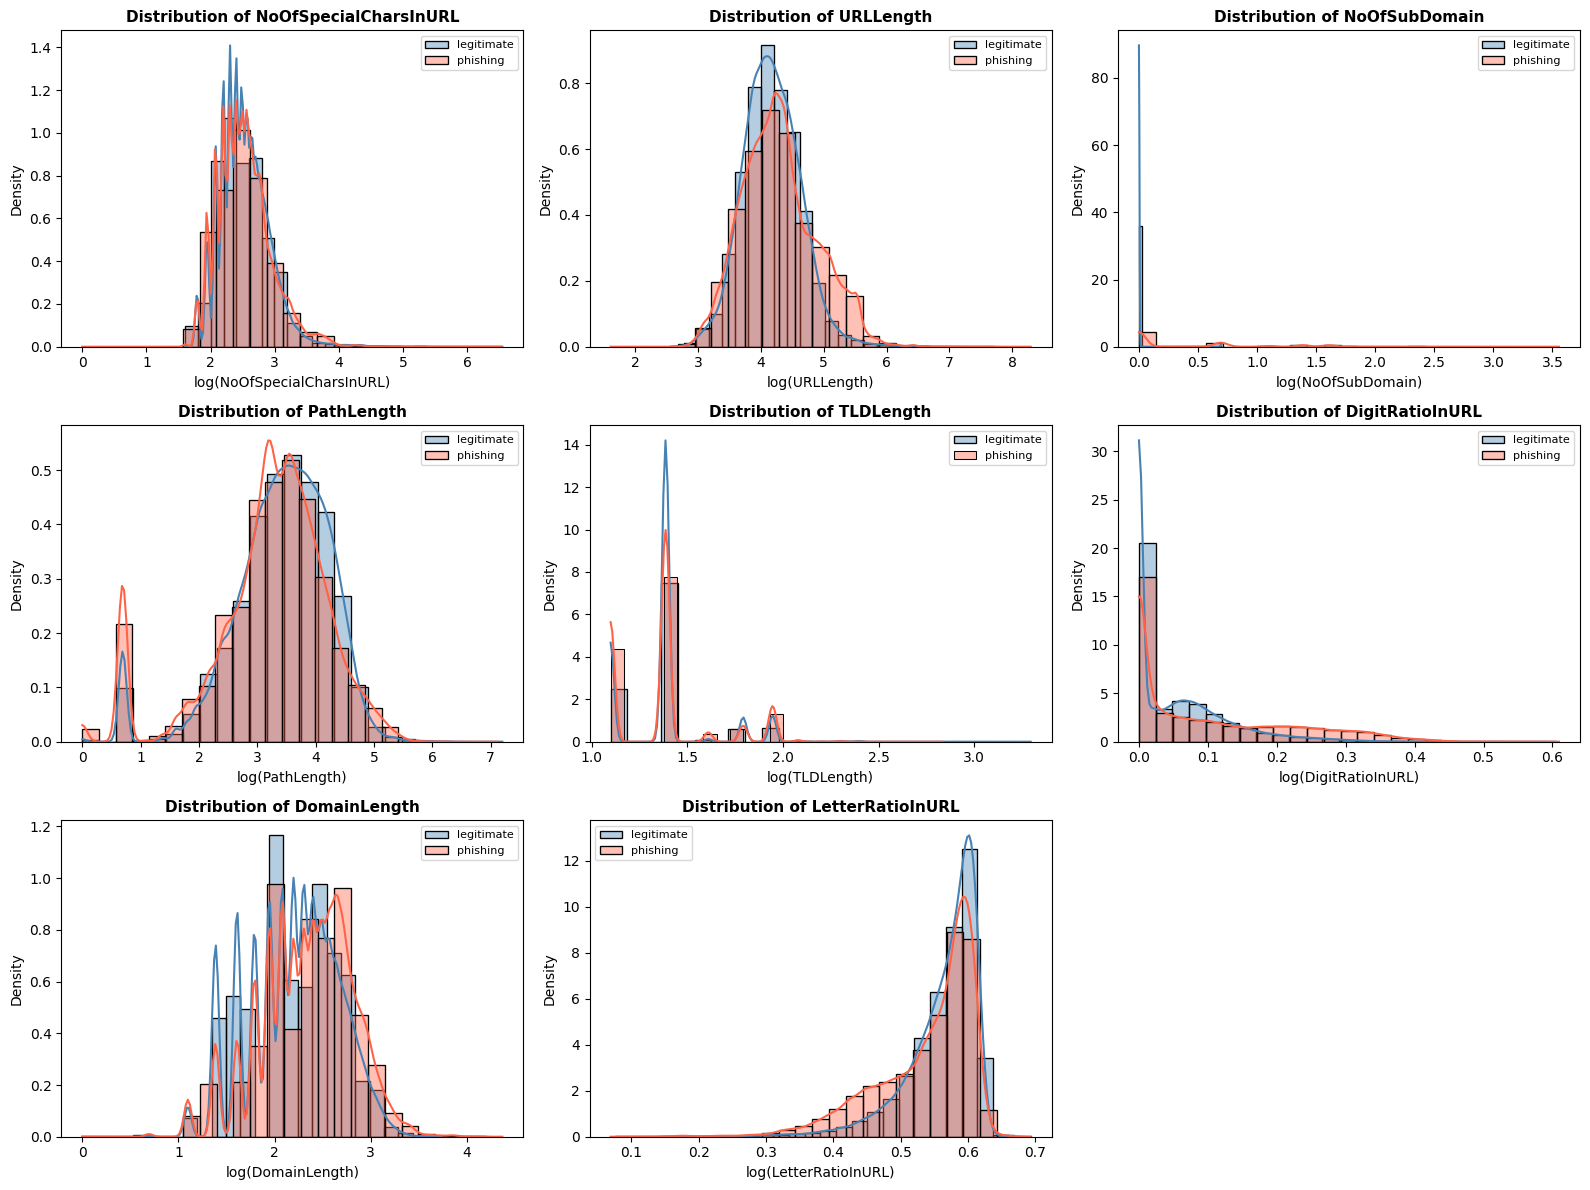

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = int(np.ceil(len(skewed_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(skewed_features.index):

    sns.histplot(
        df_log_legit[col],
        kde=True,
        stat="density",
        bins=25,
        color="steelblue",
        alpha=0.4,
        label="legitimate",
        ax=axes[i]
    )

    sns.histplot(
        df_log_phishing[col],
        kde=True,
        stat="density",
        bins=25,
        color="tomato",
        alpha=0.4,
        label="phishing",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(f"log({col})")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**DATA SPLITTING**

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold


X = df_log.drop(columns=['label'])
y = df_log['label']

def get_dist(series):
    return (series.value_counts(normalize=True).sort_index() * 100).round(2).to_dict()

print(f"Original Distribution: {get_dist(y)}\n")

# 2. Random Train-Test Split (80-20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42, stratify=None)

print("--- Random Split Distributions ---")
print(f"Train: {get_dist(y_train_r)}")
print(f"Test:  {get_dist(y_test_r)}\n")

# 3. Stratified Train-Test Split (80-20)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Stratified Split Distributions ---")
print(f"Train: {get_dist(y_train_s)}")
print(f"Test:  {get_dist(y_test_s)}\n")

# 4. 5-Fold Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Stratified 5-Fold CV Distributions ---")
for i, (train_index, val_index) in enumerate(skf.split(X, y), 1):
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    print(f"Fold {i} - Train: {get_dist(y_train_fold)} | Val: {get_dist(y_val_fold)}")

Original Distribution: {0: 55.44, 1: 44.56}

--- Random Split Distributions ---
Train: {0: 55.4, 1: 44.6}
Test:  {0: 55.63, 1: 44.37}

--- Stratified Split Distributions ---
Train: {0: 55.44, 1: 44.56}
Test:  {0: 55.44, 1: 44.56}

--- Stratified 5-Fold CV Distributions ---
Fold 1 - Train: {0: 55.44, 1: 44.56} | Val: {0: 55.44, 1: 44.56}
Fold 2 - Train: {0: 55.44, 1: 44.56} | Val: {0: 55.44, 1: 44.56}
Fold 3 - Train: {0: 55.44, 1: 44.56} | Val: {0: 55.44, 1: 44.56}
Fold 4 - Train: {0: 55.44, 1: 44.56} | Val: {0: 55.44, 1: 44.56}
Fold 5 - Train: {0: 55.44, 1: 44.56} | Val: {0: 55.44, 1: 44.56}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Display the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Quick check on the distribution of 'outcome' in the training set
print(f"\nStratified Train Distribution (%):\n{(y_train.value_counts(normalize=True) * 100).round(2)}")

X_train shape: (411675, 12)
X_test shape: (102919, 12)
y_train shape: (411675,)
y_test shape: (102919,)

Stratified Train Distribution (%):
label
0    55.44
1    44.56
Name: proportion, dtype: float64


**SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler

StandardScaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['number']).columns

X_train[num_cols] = StandardScaler.fit_transform(X_train[num_cols])
X_test[num_cols] = StandardScaler.transform(X_test[num_cols])

**FEATURE SELECTION**

In [ ]:

all_num_cols_df = df.select_dtypes(include=['number']).columns.tolist()


all_num_cols_log = df_log.select_dtypes(include=['number']).columns.tolist()


binary_cols = [col for col in df.columns if df[col].dtype == 'bool']


numerical_features_for_corr = [
    col for col in all_num_cols_df
    if col not in binary_cols and col != 'label'
]



subset_df = df[numerical_features_for_corr + ['label']]
subset_df_log = df_log[numerical_features_for_corr + ['label']]


# sebelum log
pearson_corr_before = subset_df.corr(method='pearson')['label'].drop('label')
spearman_corr_before = subset_df.corr(method='spearman')['label'].drop('label')

# sesudah log
pearson_corr_after = subset_df_log.corr(method='pearson')['label'].drop('label')
spearman_corr_after = subset_df_log.corr(method='spearman')['label'].drop('label')


correlation_comparison = pd.DataFrame({

    'Pearson_before_log': pearson_corr_before,
    'Spearman_before_log': spearman_corr_before,

    'Pearson_after_log': pearson_corr_after,
    'Spearman_after_log': spearman_corr_after
})


correlation_comparison['Spearman_change'] = (
    correlation_comparison['Spearman_after_log'].abs()
    - correlation_comparison['Spearman_before_log'].abs()
)


correlation_comparison = correlation_comparison.sort_values(
    by='Spearman_after_log',
    key=abs,
    ascending=False
)

print("\n=== Correlation Comparison (df vs df_log) ===")
display(correlation_comparison)


=== Correlation Comparison (df vs df_log) ===


,Pearson_before_log,Spearman_before_log,Pearson_after_log,Spearman_after_log,Spearman_change
IsHTTPS,-0.661068,-0.661068,-0.661068,-0.661068,0.0
NoOfSubDomain,0.340526,0.489559,0.443786,0.489559,0.0
DigitRatioInURL,0.245909,0.170865,0.240175,0.170865,0.0
LetterRatioInURL,-0.187648,-0.159149,-0.188298,-0.159149,0.0
DomainLength,0.154562,0.146040,0.146736,0.146040,0.0
PathLength,-0.056770,-0.097402,-0.108909,-0.097402,0.0
URLLength,0.137392,0.087507,0.111600,0.087507,0.0
TLDLength,-0.008979,-0.047241,-0.022373,-0.047241,0.0
NoOfSpecialCharsInURL,0.005826,-0.009119,0.000843,-0.009119,0.0
